In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import torch
print(torch.cuda.is_available())  # Doit retourner True
print(torch.cuda.get_device_name(0))  # Affiche le nom du GPU utilisé

True
Tesla T4


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_data = pd.read_hdf("/content/drive/MyDrive/PROJET fin L2 - Trading/train_dc2020.h5", 'data')
labels = pd.read_csv("/content/drive/MyDrive/PROJET fin L2 - Trading/train_labels.csv")
test_data = pd.read_hdf("/content/drive/MyDrive/PROJET fin L2 - Trading/test_dc2020.h5", 'data')

train_data.set_index('ID', inplace=True)
test_data.set_index('ID', inplace=True)
labels.set_index('ID', inplace=True)

In [ ]:
# Transformation de noms de colonnes
import re

def clean_columns(df):
    df.columns = [re.sub(r'\W+', '_', str(col)) for col in df.columns]
    return df

train_data = clean_columns(train_data)
test_data = clean_columns(test_data)

In [ ]:
train_data

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,_8_price_,_8_qty_,_8_source_id_,_8_tod_,_9_price_,_9_qty_,_9_source_id_,_9_tod_,stock_id,day_id
ID,,,,,,,,,,,,,,,,,,,,,
0,4.5,562.5,0.002330,0.093197,-25.5,-545.5,0.046598,0.046598,-0.5,0.037279,...,2.5,0.004660,4,38930876675,-3.5,0.046598,2,38930876000,387,238
1,2.5,14.5,0.001314,0.013139,-10.5,-406.5,0.013139,0.026278,-0.5,0.013139,...,1.5,0.013139,2,46336088000,1.5,0.013139,4,46336087875,437,22
2,5.0,210.0,0.010792,0.010792,-95.0,-285.0,0.032376,0.021584,-3.0,0.010253,...,5.0,0.050615,2,57584792000,0.0,0.010792,2,57583312000,7,255
3,0.5,1.5,0.006943,0.006943,-2.5,-3.5,0.006943,0.013886,-0.5,0.000069,...,0.5,0.013886,4,49549010300,0.5,0.006943,1,49549010200,48,64
4,15.0,442.0,0.035689,0.071378,-391.0,-397.0,0.035689,0.035689,3.0,0.035689,...,-12.0,0.035689,2,42452055000,-8.0,0.035689,3,42451072650,52,231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959501,21.0,525.0,0.054885,0.054885,-13.0,-568.0,0.054885,0.054885,-2.0,0.054885,...,4.0,0.005488,4,37685622400,4.0,0.021954,1,37685622225,448,37
959502,2.5,3.5,0.011474,0.011474,-2.5,-97.5,0.022949,0.022949,0.5,0.011474,...,0.5,0.002869,1,41207217975,0.5,0.006426,3,41206462575,451,13
959503,26.5,161.5,0.009052,0.004526,-0.5,-144.5,0.022630,0.009052,0.5,0.009052,...,0.5,0.004526,1,36666336825,0.5,0.018104,1,36666319950,101,45


## Etude de stocks

In [ ]:
ensemble = train_data.merge(labels, left_index=True, right_index=True)
ensemble.source_id.value_counts()

source_counts_df = ensemble['source_id'].value_counts().reset_index()
source_counts_df.columns = ['source_id', 'count']

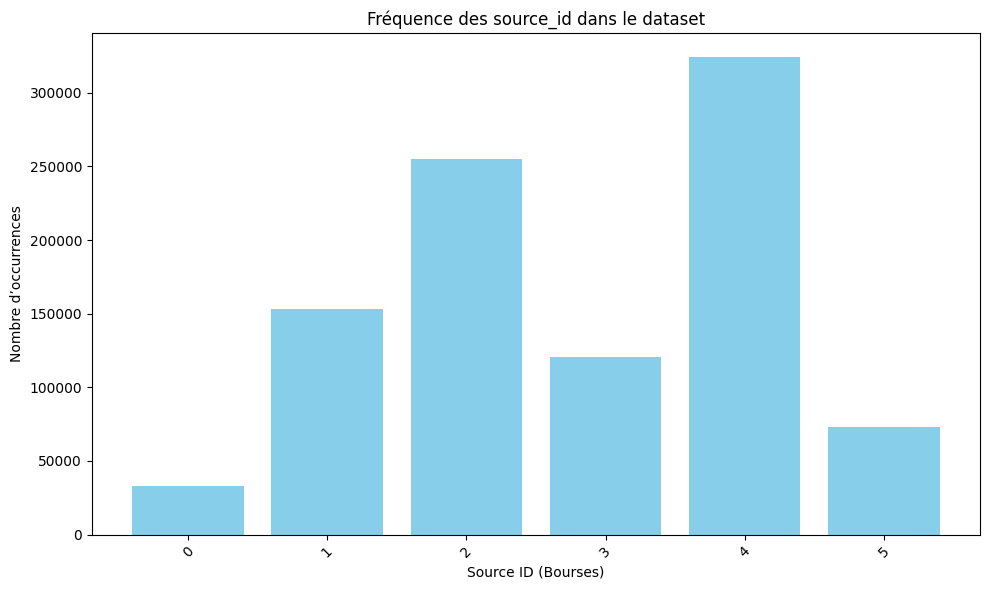

In [ ]:
# Tracer l'histogramme
plt.figure(figsize=(10, 6))
plt.bar(source_counts_df['source_id'], source_counts_df['count'], color='skyblue')
plt.xlabel('Source ID (Bourses)')
plt.ylabel('Nombre d’occurrences')
plt.title('Fréquence des source_id dans le dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

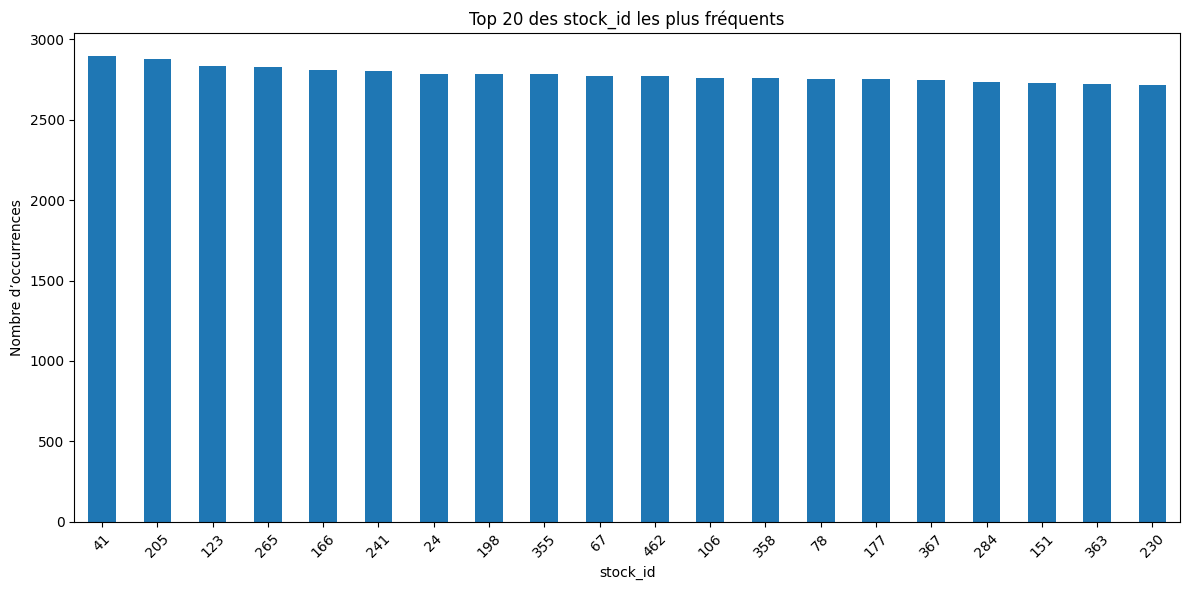

In [ ]:
# Compter les occurrences de chaque stock_id
stock_counts = train_data['stock_id'].value_counts()

# Afficher les 20 stock_id les plus fréquents
top_n = 20
top_stock_counts = stock_counts.head(top_n)

# Tracer l'histogramme
plt.figure(figsize=(12, 6))
top_stock_counts.plot(kind='bar')
plt.title(f'Top {top_n} des stock_id les plus fréquents')
plt.xlabel('stock_id')
plt.ylabel('Nombre d’occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

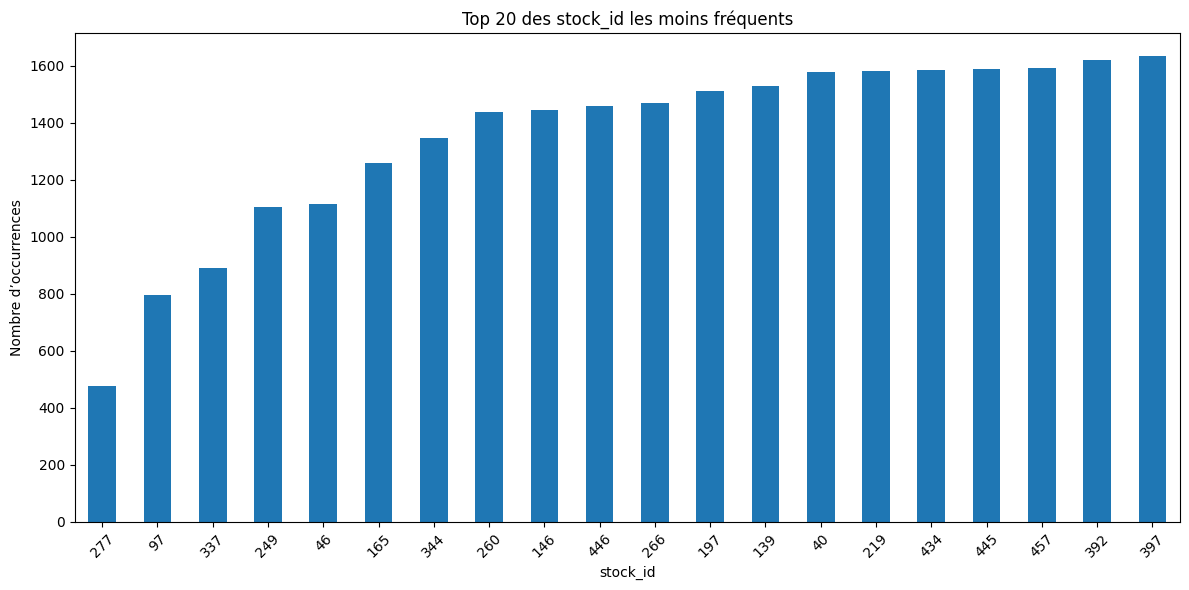

In [ ]:
# Afficher les 20 stock_id les moins fréquents
less_n = 20
less_stock_counts = stock_counts.tail(top_n)

# Trier du plus petit au plus grand
sorted_df = less_stock_counts.sort_values(ascending=True)

# Tracer l'histogramme
plt.figure(figsize=(12, 6))
sorted_df.plot(kind='bar')
plt.title(f'Top {top_n} des stock_id les moins fréquents')
plt.xlabel('stock_id')
plt.ylabel('Nombre d’occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# on étudie les stock_id qui sont présents dans le test
test_data['stock_id'].value_counts()

,count
stock_id,
443,3125
166,2902
437,2861
45,2850
424,2828
...,...
9,1237
388,1005
313,710


In [ ]:
x_filt = test_data[test_data['stock_id'] == 41]
x_filt

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,_8_price_,_8_qty_,_8_source_id_,_8_tod_,_9_price_,_9_qty_,_9_source_id_,_9_tod_,stock_id,day_id
ID,,,,,,,,,,,,,,,,,,,,,


Le stock 41 est le plus présent dans le train mais n'est pas représenté une seule fois dans le test donc le modèle va beaucoup s'entrainer sur des stocks non pertinents

In [ ]:
stock_test = test_data['stock_id'].tolist()
stock_train = train_data['stock_id'].tolist()

test_not_in_train = list(set(stock_train) - set(stock_test))
train_not_in_test = list(set(stock_test) - set(stock_train))
print(test_not_in_train)

[97, 41, 139, 46, 337, 277, 249, 445, 478]


In [ ]:
# Supprimer les lignes du set d'entrainement qui contiennent des stock_id qui ne sont pas dans le test pour entrainer le modèle que sur des données intéressantes
train_data = train_data[~train_data['stock_id'].isin(test_not_in_train)]

In [ ]:
train_data

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,_8_price_,_8_qty_,_8_source_id_,_8_tod_,_9_price_,_9_qty_,_9_source_id_,_9_tod_,stock_id,day_id
ID,,,,,,,,,,,,,,,,,,,,,
0,4.5,562.5,0.002330,0.093197,-25.5,-545.5,0.046598,0.046598,-0.5,0.037279,...,2.5,0.004660,4,38930876675,-3.5,0.046598,2,38930876000,387,238
1,2.5,14.5,0.001314,0.013139,-10.5,-406.5,0.013139,0.026278,-0.5,0.013139,...,1.5,0.013139,2,46336088000,1.5,0.013139,4,46336087875,437,22
2,5.0,210.0,0.010792,0.010792,-95.0,-285.0,0.032376,0.021584,-3.0,0.010253,...,5.0,0.050615,2,57584792000,0.0,0.010792,2,57583312000,7,255
3,0.5,1.5,0.006943,0.006943,-2.5,-3.5,0.006943,0.013886,-0.5,0.000069,...,0.5,0.013886,4,49549010300,0.5,0.006943,1,49549010200,48,64
4,15.0,442.0,0.035689,0.071378,-391.0,-397.0,0.035689,0.035689,3.0,0.035689,...,-12.0,0.035689,2,42452055000,-8.0,0.035689,3,42451072650,52,231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959501,21.0,525.0,0.054885,0.054885,-13.0,-568.0,0.054885,0.054885,-2.0,0.054885,...,4.0,0.005488,4,37685622400,4.0,0.021954,1,37685622225,448,37
959502,2.5,3.5,0.011474,0.011474,-2.5,-97.5,0.022949,0.022949,0.5,0.011474,...,0.5,0.002869,1,41207217975,0.5,0.006426,3,41206462575,451,13
959503,26.5,161.5,0.009052,0.004526,-0.5,-144.5,0.022630,0.009052,0.5,0.009052,...,0.5,0.004526,1,36666336825,0.5,0.018104,1,36666319950,101,45


In [ ]:
labels = labels.loc[train_data.index]

In [ ]:
labels

,source_id
ID,
0,2
1,2
2,2
3,4
4,2
...,...
959501,4
959502,1
959503,3


## Rajout de nouvelles colonnes

### Rajout du niveau de liquidité

In [ ]:
# Pour chaque carnet (de 0 à 5), on calcule la liquidité
for i in range(6):
    # Liquidité côté bid : bid_size + bid_size1
    train_data[f'_{i}_liquidity_bid'] = (
        train_data[f'_{i}_bid_size_'].fillna(0) + train_data[f'_{i}_bid_size1_'].fillna(0)
        )

    # Liquidité côté ask : ask_size + ask_size1
    train_data[f'_{i}_liquidity_ask'] = (
        train_data[f'_{i}_ask_size_'].fillna(0) + train_data[f'_{i}_ask_size1_'].fillna(0)
    )

    # Liquidité totale du carnet
    train_data[f'_{i}_total_liquidity'] = (
        train_data[f'_{i}_liquidity_bid'] + train_data[f'_{i}_liquidity_ask']
    )

<ipython-input-34-5621a47d2fed>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'_{i}_liquidity_bid'] = (
<ipython-input-34-5621a47d2fed>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'_{i}_liquidity_ask'] = (
<ipython-input-34-5621a47d2fed>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [ ]:
train_data

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,_2_total_liquidity,_3_liquidity_bid,_3_liquidity_ask,_3_total_liquidity,_4_liquidity_bid,_4_liquidity_ask,_4_total_liquidity,_5_liquidity_bid,_5_liquidity_ask,_5_total_liquidity
ID,,,,,,,,,,,,,,,,,,,,,
0,4.5,562.5,0.002330,0.093197,-25.5,-545.5,0.046598,0.046598,-0.5,0.037279,...,0.191053,0.093197,0.048928,0.142125,0.064306,0.068966,0.133271,0.139795,0.048928,0.188723
1,2.5,14.5,0.001314,0.013139,-10.5,-406.5,0.013139,0.026278,-0.5,0.013139,...,0.132703,0.026278,0.023650,0.049928,0.197609,0.331888,0.529497,0.091972,0.043752,0.135725
2,5.0,210.0,0.010792,0.010792,-95.0,-285.0,0.032376,0.021584,-3.0,0.010253,...,0.607706,0.043169,0.021584,0.064753,0.143859,0.011008,0.154867,0.021584,0.021584,0.043169
3,0.5,1.5,0.006943,0.006943,-2.5,-3.5,0.006943,0.013886,-0.5,0.000069,...,0.374922,0.013886,0.013886,0.027772,0.044088,0.209887,0.253975,0.023953,0.083316,0.107269
4,15.0,442.0,0.035689,0.071378,-391.0,-397.0,0.035689,0.035689,3.0,0.035689,...,0.249822,0.071378,0.071378,0.142755,0.214133,0.037830,0.251963,0.019986,0.019986,0.039971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959501,21.0,525.0,0.054885,0.054885,-13.0,-568.0,0.054885,0.054885,-2.0,0.054885,...,0.170143,0.109769,0.109769,0.219539,0.079034,0.025247,0.104281,0.049396,0.048299,0.097695
959502,2.5,3.5,0.011474,0.011474,-2.5,-97.5,0.022949,0.022949,0.5,0.011474,...,0.309811,0.034423,0.057372,0.091796,0.082042,0.114745,0.196787,0.057372,0.080321,0.137694
959503,26.5,161.5,0.009052,0.004526,-0.5,-144.5,0.022630,0.009052,0.5,0.009052,...,0.292419,0.032451,0.009821,0.042272,0.185562,0.049785,0.235347,0.153881,0.013578,0.167459


### Visualisation liquidité par bourse

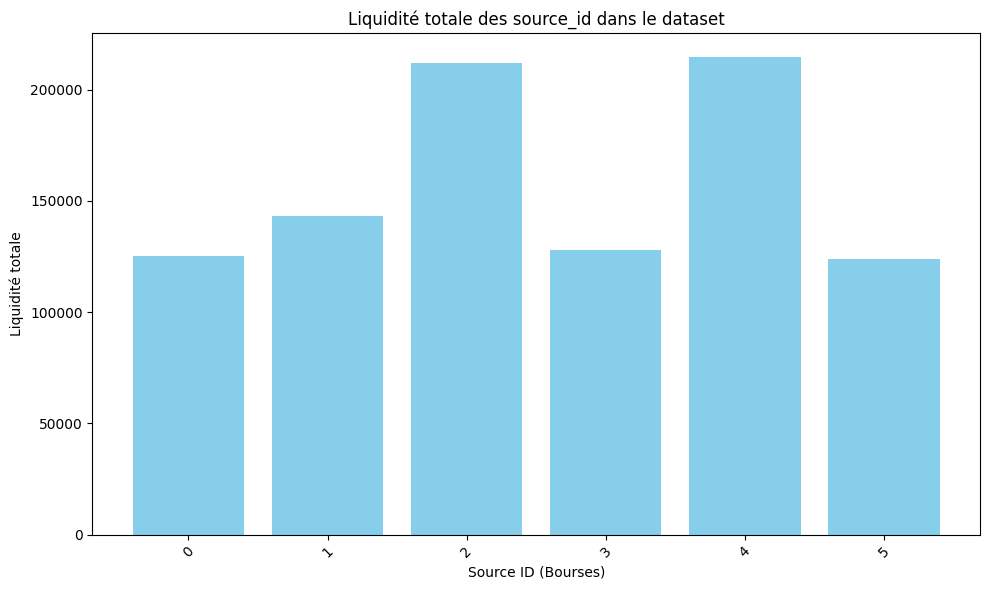

In [ ]:
# extraire les colonnes qui correspondent à total_liquidity
total_liquidity_cols = [col for col in train_data.columns if'_total_liquidity' in col]

total_liquidity_per_venue = train_data[total_liquidity_cols].sum().reset_index()
total_liquidity_per_venue.columns = ['venue', 'total_liquidity']
venue_nums = [int(col.split('_')[1]) for col in total_liquidity_per_venue['venue']]
total_liquidity_per_venue['venue']=venue_nums

# Tracer l'histogramme
plt.figure(figsize=(10, 6))
plt.bar(total_liquidity_per_venue['venue'], total_liquidity_per_venue['total_liquidity'], color='skyblue')
plt.xlabel('Source ID (Bourses)')
plt.ylabel('Liquidité totale')
plt.title('Liquidité totale des source_id dans le dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Rajout du spread

In [ ]:
for i in range(6):
    #spread pour ask-bid
    train_data[f'_{i}_spread_'] = (
        train_data[f'_{i}_ask_'].fillna(0) - train_data[f'_{i}_bid_'].fillna(0)
    )

    # spread pour ask1-bid1
    train_data[f'_{i}_spread1_'] = (
        train_data[f'_{i}_ask1_'].fillna(0) - train_data[f'_{i}_bid1_'].fillna(0)
    )

<ipython-input-37-3db110559c3c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'_{i}_spread_'] = (
<ipython-input-37-3db110559c3c>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'_{i}_spread1_'] = (
<ipython-input-37-3db110559c3c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

### Rajout des venues les plus fréquentes parmi les dernieres transactions

In [ ]:
transaction_10 = [(i, 'source_id') for i in range(0,10)]
transaction_5 = [(i, 'source_id') for i in range(0,5)]
transaction_3 = [(i, 'source_id') for i in range(0,3)]

transac_10 = [re.sub(r'\W+', '_', str(col)) for col in transaction_10]
transac_5 = [re.sub(r'\W+', '_', str(col)) for col in transaction_5]
transac_3 = [re.sub(r'\W+', '_', str(col)) for col in transaction_3]

In [ ]:
transac_10

['_0_source_id_',
 '_1_source_id_',
 '_2_source_id_',
 '_3_source_id_',
 '_4_source_id_',
 '_5_source_id_',
 '_6_source_id_',
 '_7_source_id_',
 '_8_source_id_',
 '_9_source_id_']

In [ ]:
train_data['venue_frequence_10'] = train_data[transac_10].mode(axis=1)[0]
train_data['venue_frequence_10'] = train_data['venue_frequence_10'].astype(int)

<ipython-input-40-d42383207d8d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_frequence_10'] = train_data[transac_10].mode(axis=1)[0]
<ipython-input-40-d42383207d8d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_frequence_10'] = train_data['venue_frequence_10'].astype(int)


In [ ]:
train_data['venue_frequence_5'] = train_data[transac_5].mode(axis=1)[0]
train_data['venue_frequence_5'] = train_data['venue_frequence_5'].astype(int)

<ipython-input-41-164bfac92b60>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_frequence_5'] = train_data[transac_5].mode(axis=1)[0]
<ipython-input-41-164bfac92b60>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_frequence_5'] = train_data['venue_frequence_5'].astype(int)


In [ ]:
train_data['venue_frequence_3'] = train_data[transac_3].mode(axis=1)[0]
train_data['venue_frequence_3'] = train_data['venue_frequence_3'].astype(int)

<ipython-input-42-2464971157f7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_frequence_3'] = train_data[transac_3].mode(axis=1)[0]
<ipython-input-42-2464971157f7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_frequence_3'] = train_data['venue_frequence_3'].astype(int)


### Rajout de la venue avec le plus grande bid/ask size

In [ ]:
# Créer 2 nouvelles colonnes avec la bourse avec le plus grand bid size et ask size
bid_size_cols = [col for col in train_data.columns if 'bid_size_' in col]
ask_size_cols = [col for col in train_data.columns if 'ask_size_' in col]
train_data['venue_with_max_bidsize'] = np.nanargmax(train_data[bid_size_cols].values, axis=1)
train_data['venue_with_max_asksize'] = np.nanargmax(train_data[ask_size_cols].values, axis=1)

<ipython-input-43-cc2fde6a2d34>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_max_bidsize'] = np.nanargmax(train_data[bid_size_cols].values, axis=1)
<ipython-input-43-cc2fde6a2d34>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_max_asksize'] = np.nanargmax(train_data[ask_size_cols].values, axis=1)


### Rajout de la venue avec le meilleur bid et ask

In [ ]:
#Créer 2 nouvelles colonnes avec la bourse avec le meilleur bid (le bid le plus élevé) et le meilleur ask (le ask le moins élevé)
bid_cols = [col for col in train_data.columns if '_bid_' in col and 'size' not in col]
ask_cols = [col for col in train_data.columns if '_ask_' in col and 'size' not in col]
train_data['venue_with_best_bid'] = np.nanargmax(train_data[bid_cols].values, axis=1)
train_data['venue_with_best_ask'] = np.nanargmin(train_data[ask_cols].values, axis=1)
train_data

<ipython-input-44-0695e68e7960>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_best_bid'] = np.nanargmax(train_data[bid_cols].values, axis=1)
<ipython-input-44-0695e68e7960>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_best_ask'] = np.nanargmin(train_data[ask_cols].values, axis=1)


,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,_4_spread1_,_5_spread_,_5_spread1_,venue_frequence_10,venue_frequence_5,venue_frequence_3,venue_with_max_bidsize,venue_with_max_asksize,venue_with_best_bid,venue_with_best_ask
ID,,,,,,,,,,,,,,,,,,,,,
0,4.5,562.5,0.002330,0.093197,-25.5,-545.5,0.046598,0.046598,-0.5,0.037279,...,18.0,8.0,128.0,2,2,2,0,4,5,2
1,2.5,14.5,0.001314,0.013139,-10.5,-406.5,0.013139,0.026278,-0.5,0.013139,...,6.0,4.0,6.0,4,4,4,4,4,1,1
2,5.0,210.0,0.010792,0.010792,-95.0,-285.0,0.032376,0.021584,-3.0,0.010253,...,108.0,215.0,289.0,2,2,2,0,2,1,0
3,0.5,1.5,0.006943,0.006943,-2.5,-3.5,0.006943,0.013886,-0.5,0.000069,...,3.0,2.0,4.0,2,2,2,2,2,4,0
4,15.0,442.0,0.035689,0.071378,-391.0,-397.0,0.035689,0.035689,3.0,0.035689,...,53.0,12.0,18.0,2,0,0,4,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959501,21.0,525.0,0.054885,0.054885,-13.0,-568.0,0.054885,0.054885,-2.0,0.054885,...,15.0,12.0,18.0,4,4,4,0,0,1,1
959502,2.5,3.5,0.011474,0.011474,-2.5,-97.5,0.022949,0.022949,0.5,0.011474,...,4.0,2.0,4.0,2,2,2,2,1,1,2
959503,26.5,161.5,0.009052,0.004526,-0.5,-144.5,0.022630,0.009052,0.5,0.009052,...,4.0,1.0,3.0,1,3,3,2,2,0,2


### Rajout de corrélation entre bid_size et ask_size

In [ ]:
# Nouvelle colonne pour voir à quel point c'est correlé le bid_size et ask_size par rapport au endroit ou on echange

# Comparaison élément par élément
matches = (train_data[bid_size_cols].values == train_data[ask_size_cols].values)

# Récupérer les indices (bourses) où c’est égal
train_data['matching_venues'] = [
    [i for i, match in enumerate(row) if match] for row in matches
]

for i in range(6):
    train_data[f'matching_venue_{i}'] = train_data['matching_venues'].apply(
        lambda lst: int(i in lst if isinstance(lst, list) else False)
        )

#Drop la colonne matching_venues car n'est plus utilisée
train_data.drop(columns=['matching_venues'], inplace=True)

<ipython-input-45-914f57406485>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['matching_venues'] = [
<ipython-input-45-914f57406485>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'matching_venue_{i}'] = train_data['matching_venues'].apply(
<ipython-input-45-914f57406485>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

### Nouvelle colonne meilleur spread et suppression des autres

In [ ]:
# Rajout du mid_spread
spread_cols = [col for col in train_data.columns if '_spread_' in col and 'size' not in col]
spread1_cols = [col for col in train_data.columns if '_spread1_' in col and 'size' not in col]
train_data['venue_with_min_spread'] = np.nanargmin(train_data[spread_cols].values, axis=1)
train_data['venue_with_min_spread1'] = np.nanargmin(train_data[spread1_cols].values, axis=1)
spread1_cols

<ipython-input-46-295ab9fab51e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_min_spread'] = np.nanargmin(train_data[spread_cols].values, axis=1)
<ipython-input-46-295ab9fab51e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_min_spread1'] = np.nanargmin(train_data[spread1_cols].values, axis=1)


['_0_spread1_',
 '_1_spread1_',
 '_2_spread1_',
 '_3_spread1_',
 '_4_spread1_',
 '_5_spread1_']

In [ ]:
spread1_cols = [col for col in train_data.columns if '_spread1_' in col and 'size' not in col]
train_data['venue_with_min_spread1'] = np.nanargmin(train_data[spread1_cols].values, axis=1)
spread1_cols

<ipython-input-47-0fc4799ad7ac>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['venue_with_min_spread1'] = np.nanargmin(train_data[spread1_cols].values, axis=1)


['_0_spread1_',
 '_1_spread1_',
 '_2_spread1_',
 '_3_spread1_',
 '_4_spread1_',
 '_5_spread1_']

In [ ]:
#Drop les colonnes spread car n'est plus utilisée
train_data.drop(columns=spread_cols, inplace=True)

<ipython-input-48-65bf5b5dfbea>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data.drop(columns=spread_cols, inplace=True)


In [ ]:
train_data.drop(columns=spread1_cols, inplace=True)

<ipython-input-49-c397fac57213>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data.drop(columns=spread1_cols, inplace=True)


In [ ]:
train_data

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,venue_with_best_bid,venue_with_best_ask,matching_venue_0,matching_venue_1,matching_venue_2,matching_venue_3,matching_venue_4,matching_venue_5,venue_with_min_spread,venue_with_min_spread1
ID,,,,,,,,,,,,,,,,,,,,,
0,4.5,562.5,0.002330,0.093197,-25.5,-545.5,0.046598,0.046598,-0.5,0.037279,...,5,2,0,0,0,0,0,0,2,2
1,2.5,14.5,0.001314,0.013139,-10.5,-406.5,0.013139,0.026278,-0.5,0.013139,...,1,1,0,1,0,0,0,0,1,1
2,5.0,210.0,0.010792,0.010792,-95.0,-285.0,0.032376,0.021584,-3.0,0.010253,...,1,0,0,0,0,0,0,1,2,2
3,0.5,1.5,0.006943,0.006943,-2.5,-3.5,0.006943,0.013886,-0.5,0.000069,...,4,0,1,0,0,1,0,0,4,4
4,15.0,442.0,0.035689,0.071378,-391.0,-397.0,0.035689,0.035689,3.0,0.035689,...,2,5,1,0,1,1,0,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959501,21.0,525.0,0.054885,0.054885,-13.0,-568.0,0.054885,0.054885,-2.0,0.054885,...,1,1,1,1,0,1,0,0,1,1
959502,2.5,3.5,0.011474,0.011474,-2.5,-97.5,0.022949,0.022949,0.5,0.011474,...,1,2,0,0,0,0,0,0,2,2
959503,26.5,161.5,0.009052,0.004526,-0.5,-144.5,0.022630,0.009052,0.5,0.009052,...,0,2,0,0,0,0,0,0,2,2


In [ ]:
test_data

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,_8_price_,_8_qty_,_8_source_id_,_8_tod_,_9_price_,_9_qty_,_9_source_id_,_9_tod_,stock_id,day_id
ID,,,,,,,,,,,,,,,,,,,,,
959506,1.5,2.5,0.003510,0.003510,-0.5,-1.5,0.010530,0.007020,0.5,0.003510,...,-0.5,0.003510,4,53384312350,-0.5,0.003510,4,53384312350,444,183
959507,1.5,5.5,0.038110,0.038110,-5.5,-9.5,0.038110,0.038110,0.5,0.022104,...,0.5,0.053735,5,55775839675,0.5,0.057546,5,55775839675,95,226
959508,868.0,948.0,0.053937,0.053937,-50.0,-1127.0,0.161812,0.053937,-30.0,0.053937,...,-30.0,0.045847,4,35410791925,-30.0,0.008091,4,35410791925,399,177
959509,3.0,6.0,0.073099,0.036550,-2.0,-6.0,0.036550,0.036550,0.0,0.014620,...,-4.0,0.000365,1,35088506100,-4.0,0.033991,1,35088506100,305,248
959510,8.5,212.5,0.028645,0.028645,-12.5,-208.5,0.028645,0.028645,-1.5,0.028645,...,-1.5,0.021770,4,41953728050,-1.5,0.028645,2,41953728000,70,177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913398,0.5,9.5,0.017726,0.025323,-4.5,-88.5,0.025323,0.025323,0.5,0.004558,...,1.5,0.021778,5,56224244250,1.5,0.004052,4,56224226275,235,140
1913399,2.5,6.5,0.021777,0.021777,-7.5,-10.5,0.021777,0.029036,-0.5,0.002033,...,0.5,0.029036,4,37327162075,0.5,0.029036,4,37327162075,45,128
1913400,7.0,14.0,0.046296,0.046296,-6.0,-15.0,0.046296,0.046296,-1.0,0.046296,...,8.0,0.018056,4,42650698450,7.0,0.000463,5,42650698400,227,84


## Train Test Split


In [ ]:
# Conversion en categorial_feature
categorial_features = ['venue_with_max_bidsize', 'venue_with_max_asksize', 'venue_with_best_bid', 'venue_with_best_ask', 'venue_with_min_spread', 'venue_with_min_spread1']
train_data[categorial_features] = train_data[categorial_features].astype('category')
train_data

<ipython-input-52-dfb200f1d796>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[categorial_features] = train_data[categorial_features].astype('category')


,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,venue_with_best_bid,venue_with_best_ask,matching_venue_0,matching_venue_1,matching_venue_2,matching_venue_3,matching_venue_4,matching_venue_5,venue_with_min_spread,venue_with_min_spread1
ID,,,,,,,,,,,,,,,,,,,,,
0,4.5,562.5,0.002330,0.093197,-25.5,-545.5,0.046598,0.046598,-0.5,0.037279,...,5,2,0,0,0,0,0,0,2,2
1,2.5,14.5,0.001314,0.013139,-10.5,-406.5,0.013139,0.026278,-0.5,0.013139,...,1,1,0,1,0,0,0,0,1,1
2,5.0,210.0,0.010792,0.010792,-95.0,-285.0,0.032376,0.021584,-3.0,0.010253,...,1,0,0,0,0,0,0,1,2,2
3,0.5,1.5,0.006943,0.006943,-2.5,-3.5,0.006943,0.013886,-0.5,0.000069,...,4,0,1,0,0,1,0,0,4,4
4,15.0,442.0,0.035689,0.071378,-391.0,-397.0,0.035689,0.035689,3.0,0.035689,...,2,5,1,0,1,1,0,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959501,21.0,525.0,0.054885,0.054885,-13.0,-568.0,0.054885,0.054885,-2.0,0.054885,...,1,1,1,1,0,1,0,0,1,1
959502,2.5,3.5,0.011474,0.011474,-2.5,-97.5,0.022949,0.022949,0.5,0.011474,...,1,2,0,0,0,0,0,0,2,2
959503,26.5,161.5,0.009052,0.004526,-0.5,-144.5,0.022630,0.009052,0.5,0.009052,...,0,2,0,0,0,0,0,0,2,2


In [ ]:
train_data['venue_with_best_bid'].dtype

CategoricalDtype(categories=[0, 1, 2, 3, 4, 5], ordered=False, categories_dtype=int64)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(train_data, labels, test_size=0.2, random_state=42)

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

model = LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.1, random_state=42, device_type='gpu',        # Active le GPU
    boosting_type='gbdt',     # obligatoire pour GPU (pas 'dart' ni 'rf')
    gpu_use_dp=False,         # True = double précision (plus lent)
    max_bin=255 )
model.fit(x_train, y_train, categorical_feature=categorial_features)

y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 25769
[LightGBM] [Info] Number of data points in the train set: 757325, number of used features: 129
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 125 dense feature groups (92.45 MB) transferred to GPU in 0.119840 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -3.374083
[LightGBM] [Info] Start training from score -1.836634
[LightGBM] [Info] Start training from score -1.321173
[LightGBM] [Info] Start training from score -2.078815
[LightGBM] [Info] Start training from score -1.083358
[LightGBM] [Info] Start training from score -2.576496
Accuracy: 0.505772927978366


Accuracy : 0.504960 sans drop les stocks qui ne sont pas dans test_data
et 0.4042253 avec (sans supprimer les spreads et avec venue_with_min_spread).
Après avoir supprimé, on a un score de 0.50472

Avec tranformation des 'venue_with_....' en type catégorie : 0.5053028

In [ ]:
importance = model.booster_.feature_importance(importance_type='gain')
feature_names = model.booster_.feature_name()

# Créer un DataFrame trié
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

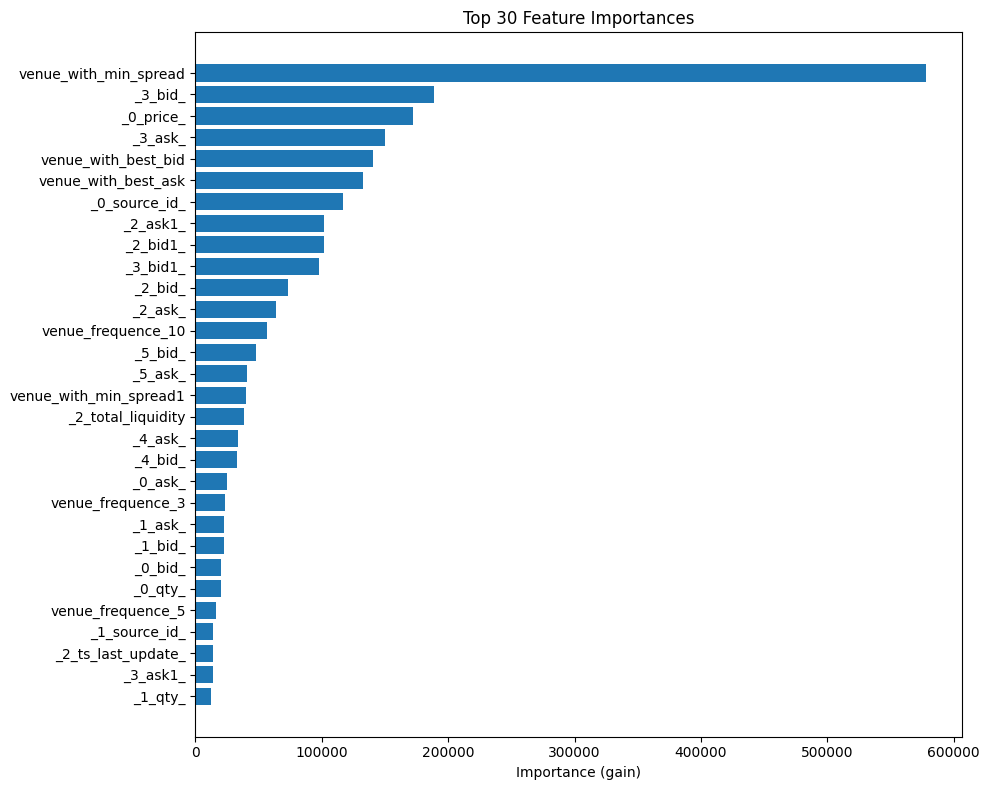

In [ ]:
feature_importance_df
# Top 30 variables
top_n = 30
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance (gain)")
plt.title("Top {} Feature Importances".format(top_n))
plt.tight_layout()
plt.show()

## XGBoost

In [ ]:
from xgboost import XGBClassifier

best_params = {'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 10,
 'n_estimators': 200,
 'subsample': 0.8}

m_XGB = XGBClassifier(**best_params,enable_categorical=True, tree_method='gpu_hist', predictor='gpu_predictor')
m_XGB.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:02:45] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:02:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
y_pred_m_XGB = m_XGB.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_m_XGB))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:05:22] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:05:22] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.5040827752308115


Avec XGBClassifier: Accuracy: 0.5040827752308115

## Modifications sur test_data

In [ ]:
# Pour chaque carnet (de 0 à 5), on calcule la liquidité
for i in range(6):
    # Liquidité côté bid : bid_size + bid_size1
    test_data[f'_{i}_liquidity_bid'] = (
        test_data[f'_{i}_bid_size_'].fillna(0) + test_data[f'_{i}_bid_size1_'].fillna(0)
        )

    # Liquidité côté ask : ask_size + ask_size1
    test_data[f'_{i}_liquidity_ask'] = (
        test_data[f'_{i}_ask_size_'].fillna(0) + test_data[f'_{i}_ask_size1_'].fillna(0)
    )

    # Liquidité totale du carnet
    test_data[f'_{i}_total_liquidity'] = (
        test_data[f'_{i}_liquidity_bid'] + test_data[f'_{i}_liquidity_ask']
    )

#Rajout spread
for i in range(6):
    #spread pour ask-bid
    test_data[f'_{i}_spread_'] = (
        test_data[f'_{i}_ask_'].fillna(0) - test_data[f'_{i}_bid_'].fillna(0)
    )

    # spread pour ask1-bid1
    test_data[f'_{i}_spread1_'] = (
        test_data[f'_{i}_ask1_'].fillna(0) - test_data[f'_{i}_bid1_'].fillna(0)
        )

# Rajout du mid_spread
spread_cols = [col for col in test_data.columns if '_spread_' in col and 'size' not in col]
spread1_cols = [col for col in test_data.columns if '_spread1_' in col and 'size' not in col]
test_data['venue_with_min_spread'] = np.nanargmin(test_data[spread_cols].values, axis=1)
test_data['venue_with_min_spread1'] = np.nanargmin(test_data[spread1_cols].values, axis=1)
#Drop les colonnes spread car n'est plus utilisée
test_data.drop(columns=spread_cols, inplace=True)
test_data.drop(columns=spread1_cols, inplace=True)

In [ ]:
transaction_10 = [(i, 'source_id') for i in range(0,10)]
transaction_5 = [(i, 'source_id') for i in range(0,5)]
transaction_3 = [(i, 'source_id') for i in range(0,3)]

transac_10 = [re.sub(r'\W+', '_', str(col)) for col in transaction_10]
transac_5 = [re.sub(r'\W+', '_', str(col)) for col in transaction_5]
transac_3 = [re.sub(r'\W+', '_', str(col)) for col in transaction_3]

In [ ]:
#frequence des transactions
test_data['venue_frequence_10'] = test_data[transac_10].mode(axis=1)[0]
test_data['venue_frequence_10'] = test_data['venue_frequence_10'].astype(int)

In [ ]:
test_data['venue_frequence_5'] = test_data[transac_5].mode(axis=1)[0]
test_data['venue_frequence_5'] = test_data['venue_frequence_5'].astype(int)

In [ ]:
test_data['venue_frequence_3'] = test_data[transac_3].mode(axis=1)[0]
test_data['venue_frequence_3'] = test_data['venue_frequence_3'].astype(int)

In [ ]:
# Créer 2 nouvelles colonnes avec la bourse avec le plus grand bid size et ask size
bid_size_cols = [col for col in test_data.columns if 'bid_size_' in col]
ask_size_cols = [col for col in test_data.columns if 'ask_size_' in col]
test_data['venue_with_max_bidsize'] = np.nanargmax(test_data[bid_size_cols].values, axis=1)
test_data['venue_with_max_asksize'] = np.nanargmax(test_data[ask_size_cols].values, axis=1)

#Créer 2 nouvelles colonnes avec la bourse avec le meilleur bid (le bid le plus élevé) et le meilleur ask (le ask le moins élevé)
bid_cols = [col for col in test_data.columns if '_bid_' in col and 'size' not in col]
ask_cols = [col for col in test_data.columns if '_ask_' in col and 'size' not in col]
test_data['venue_with_best_bid'] = np.nanargmax(test_data[bid_cols].values, axis=1)
test_data['venue_with_best_ask'] = np.nanargmin(test_data[ask_cols].values, axis=1)


# Nouvelle colonne pour voir à quel point c'est correlé le bid_size et ask_size par rapport au endroit ou on echange

# Comparaison élément par élément
matches = (test_data[bid_size_cols].values == test_data[ask_size_cols].values)

# Récupérer les indices (bourses) où c’est égal
test_data['matching_venues'] = [
    [i for i, match in enumerate(row) if match] for row in matches
]

for i in range(6):
    test_data[f'matching_venue_{i}'] = test_data['matching_venues'].apply(
        lambda lst: int(i in lst if isinstance(lst, list) else False)
        )

#Drop la colonne matching_venues car n'est plus utilisée
test_data.drop(columns=['matching_venues'], inplace=True)

In [ ]:
# Conversion en categorial_feature
categorial_features = ['venue_with_max_bidsize', 'venue_with_max_asksize', 'venue_with_best_bid', 'venue_with_best_ask', 'venue_with_min_spread', 'venue_with_min_spread1']
test_data[categorial_features] = test_data[categorial_features].astype('category')
test_data

,_0_ask_,_0_ask1_,_0_ask_size_,_0_ask_size1_,_0_bid_,_0_bid1_,_0_bid_size_,_0_bid_size1_,_0_price_,_0_qty_,...,venue_with_max_bidsize,venue_with_max_asksize,venue_with_best_bid,venue_with_best_ask,matching_venue_0,matching_venue_1,matching_venue_2,matching_venue_3,matching_venue_4,matching_venue_5
ID,,,,,,,,,,,,,,,,,,,,,
959506,1.5,2.5,0.003510,0.003510,-0.5,-1.5,0.010530,0.007020,0.5,0.003510,...,4,1,0,1,0,0,0,0,0,0
959507,1.5,5.5,0.038110,0.038110,-5.5,-9.5,0.038110,0.038110,0.5,0.022104,...,2,2,1,0,1,1,0,1,0,0
959508,868.0,948.0,0.053937,0.053937,-50.0,-1127.0,0.161812,0.053937,-30.0,0.053937,...,0,5,1,1,0,0,0,0,1,0
959509,3.0,6.0,0.073099,0.036550,-2.0,-6.0,0.036550,0.036550,0.0,0.014620,...,4,0,1,1,0,1,1,0,0,1
959510,8.5,212.5,0.028645,0.028645,-12.5,-208.5,0.028645,0.028645,-1.5,0.028645,...,4,4,4,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913398,0.5,9.5,0.017726,0.025323,-4.5,-88.5,0.025323,0.025323,0.5,0.004558,...,1,2,1,0,0,0,0,0,1,0
1913399,2.5,6.5,0.021777,0.021777,-7.5,-10.5,0.021777,0.029036,-0.5,0.002033,...,1,2,2,1,1,1,0,1,0,1
1913400,7.0,14.0,0.046296,0.046296,-6.0,-15.0,0.046296,0.046296,-1.0,0.046296,...,0,5,1,4,1,0,0,1,0,0


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

model_lgb = LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.1, random_state=42,device_type='gpu',        # Active le GPU
    boosting_type='gbdt',     # obligatoire pour GPU (pas 'dart' ni 'rf')
    gpu_use_dp=False,         # True = double précision (plus lent)
    max_bin=255 )
model_lgb.fit(train_data, labels,categorical_feature=categorial_features)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.468149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25782
[LightGBM] [Info] Number of data points in the train set: 946657, number of used features: 129
[LightGBM] [Info] Start training from score -3.373760
[LightGBM] [Info] Start training from score -1.836737
[LightGBM] [Info] Start training from score -1.321565
[LightGBM] [Info] Start training from score -2.079223
[LightGBM] [Info] Start training from score -1.082814
[LightGBM] [Info] Start training from score -2.576799


LGBMClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred_lgb = model_lgb.predict(test_data)

In [ ]:
y_pred_lgb = pd.Series(y_pred_lgb, index=test_data.index, name='prediction')
y_pred_lgb

,prediction
ID,
959506,4
959507,2
959508,4
959509,4
959510,4
...,...
1913398,2
1913399,2
1913400,0


In [ ]:
y_pred_lgb.to_csv('predictions_lgb.csv', index=True)

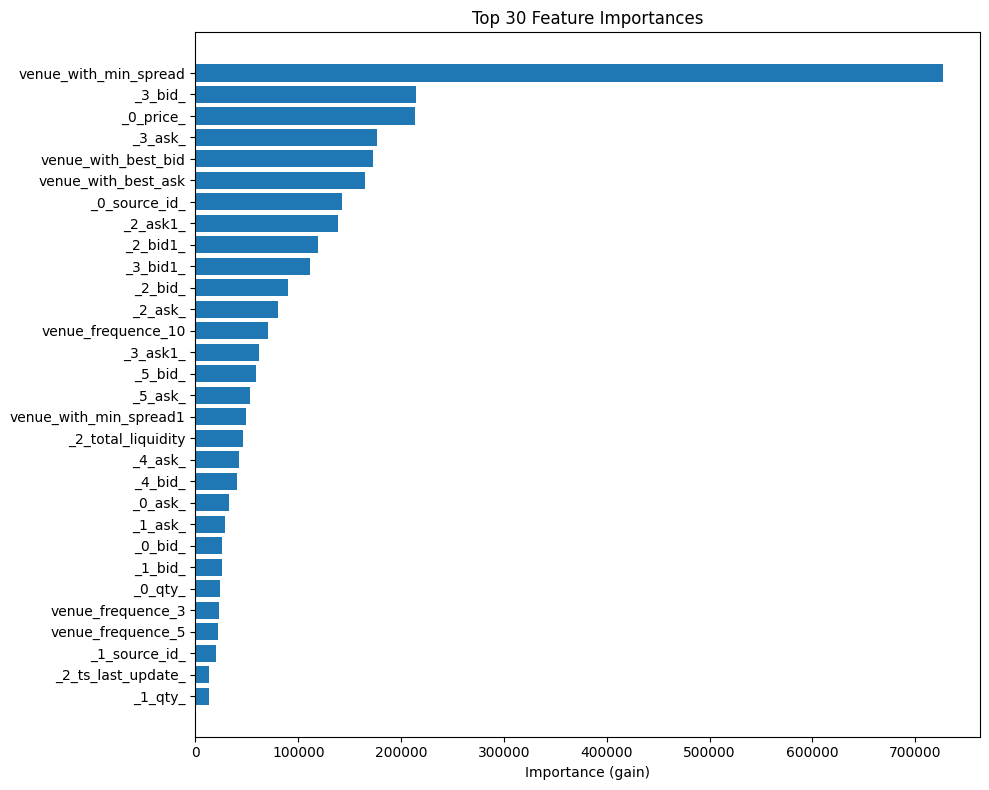

In [ ]:
importance = model_lgb.booster_.feature_importance(importance_type='gain')
feature_names = model_lgb.booster_.feature_name()

# Créer un DataFrame trié
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feature_importance_df
# Top 30 variables
top_n = 30
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance (gain)")
plt.title("Top {} Feature Importances".format(top_n))
plt.tight_layout()
plt.show()

In [ ]:
less_features = feature_importance_df.tail(top_n)
less_features

# utilisation xgboost pour classifier

In [ ]:
from xgboost import XGBClassifier

best_params = {'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 10,
 'n_estimators': 200,
 'subsample': 0.8}

m_1 = XGBClassifier(**best_params,enable_categorical=True, tree_method='gpu_hist', predictor='gpu_predictor')
m_1.fit(train_data,labels)

NameError: name 'train_data' is not defined

In [ ]:
y_pred = m_1.predict(test_data)

In [ ]:
y_pred = pd.Series(y_pred, index=test_data.index, name='prediction')
y_pred

In [ ]:
y_pred.to_csv('predictions-XGB.csv', index=True)